# Major Commodities Overview
Import a broad set of liquid commodity proxy ETFs and plot their relative behaviour across energy, metals, and agriculture. Using ETFs avoids the roll and negative-price artifacts that can distort front-month futures series.

In [ ]:
%pip install matplotlib pandas yfinance

             last_price  1m_return_pct  3m_return_pct  1y_return_pct  \
Ticker                                                                 
WTI Crude        116.04          -4.63          63.14          74.55   
Soybeans          24.52           1.41          12.01          13.47   
Wheat             22.47          -3.19          11.96          -4.99   
Gold             445.93           0.27           5.34          49.75   
Corn              17.95          -3.65           5.28          -7.95   
Natural Gas       10.84         -14.44           5.24         -37.56   
Copper            37.29          10.82           1.41          28.54   
Silver            73.63           7.18         -11.63         150.36   

             63d_vol_annualized_pct  drawdown_from_peak_pct  max_drawdown_pct  
Ticker                                                                         
WTI Crude                     63.61                  -16.48            -86.75  
Soybeans                      12.99    

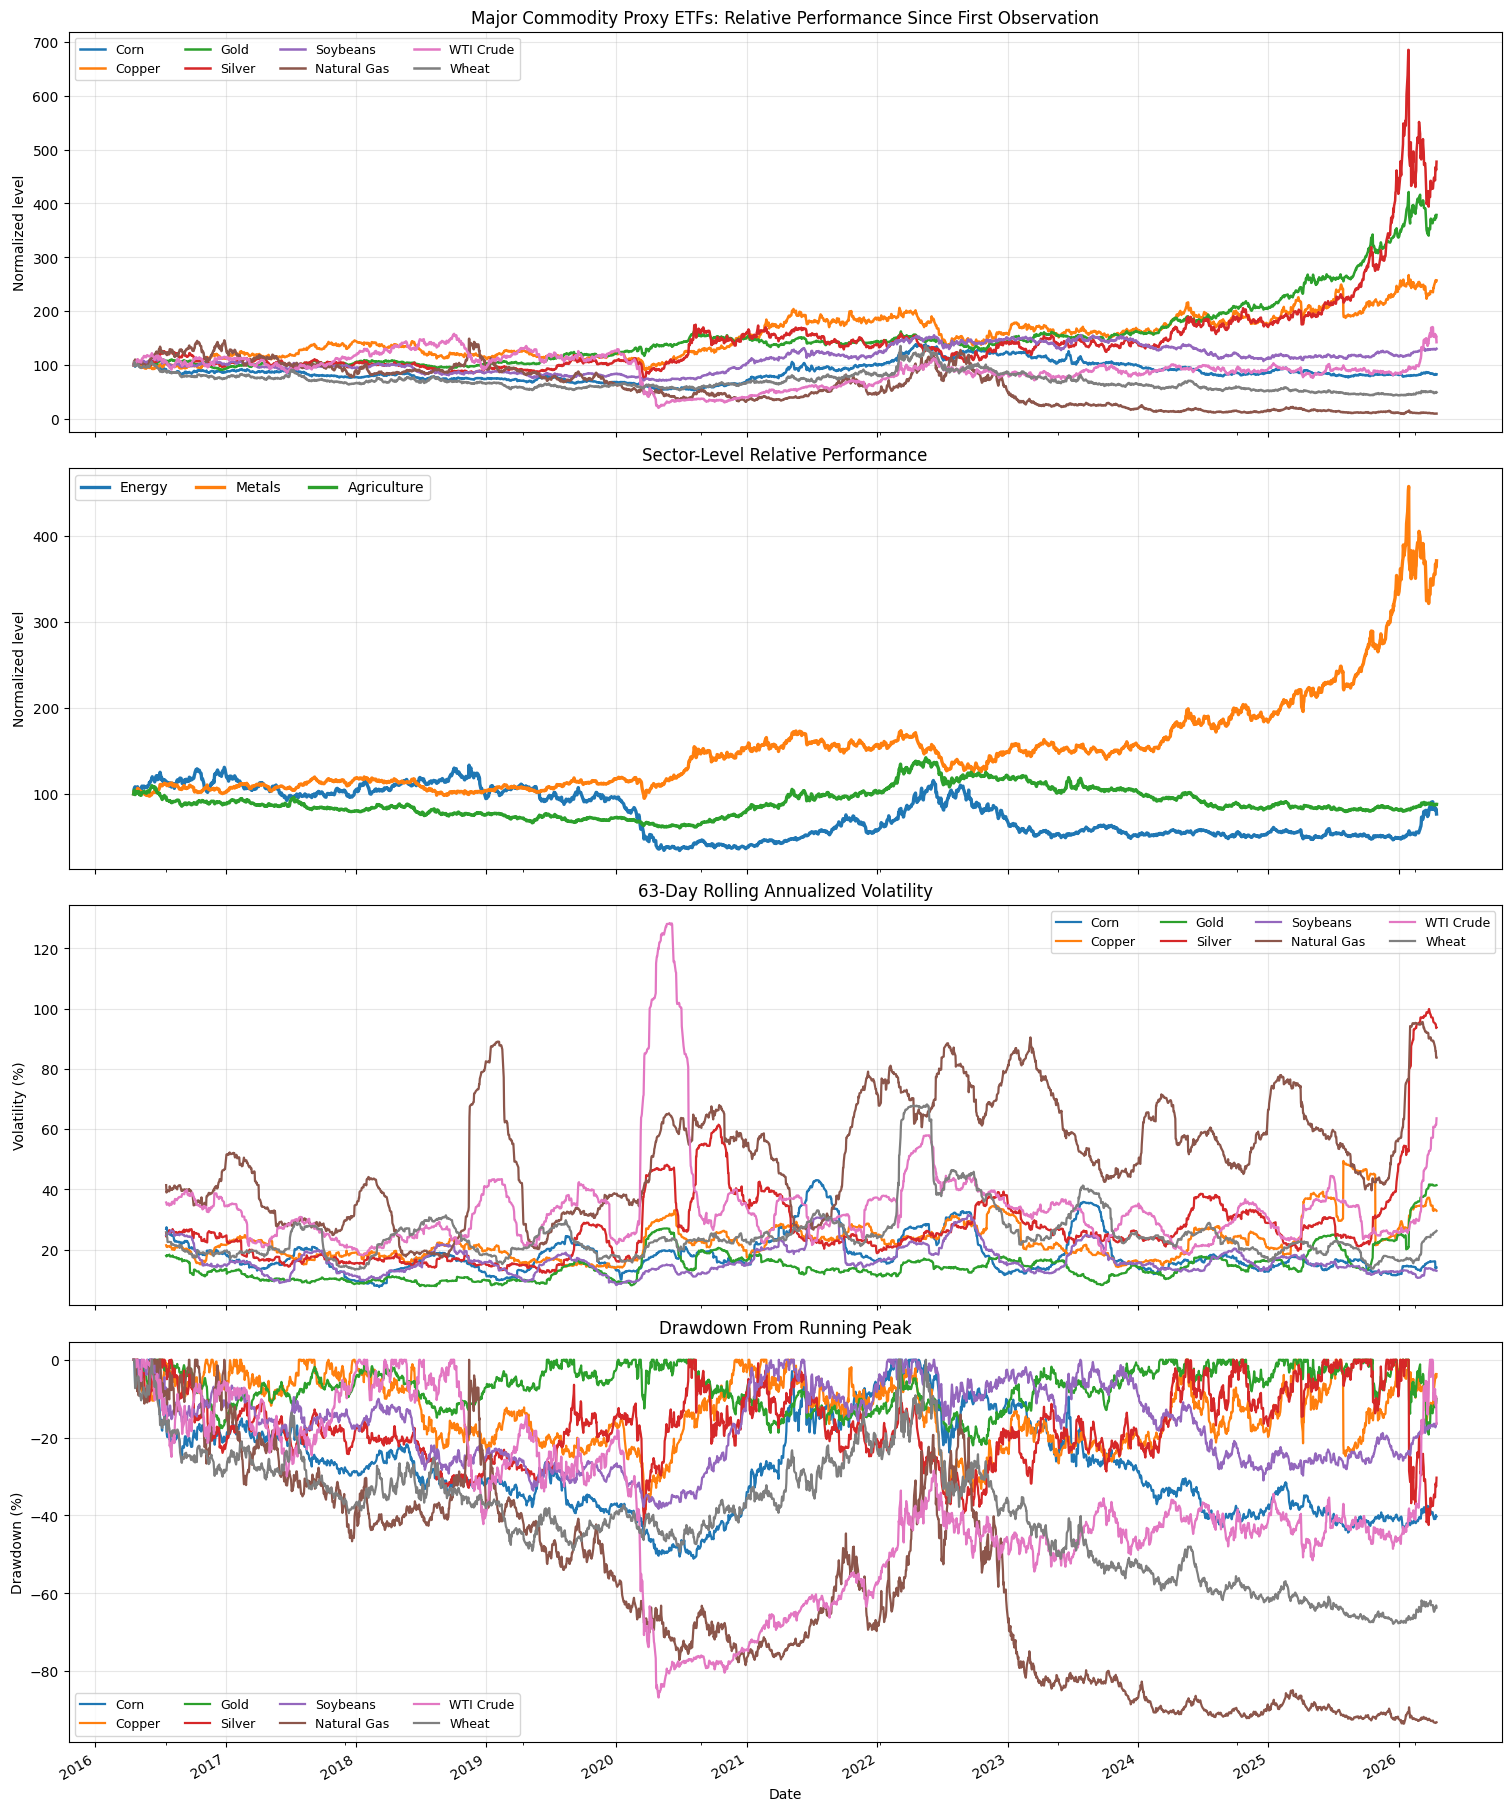

In [4]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

commodity_map = {
    "Gold": "GLD",
    "Silver": "SLV",
    "Copper": "CPER",
    "WTI Crude": "USO",
    "Natural Gas": "UNG",
    "Corn": "CORN",
    "Wheat": "WEAT",
    "Soybeans": "SOYB",
}

raw = yf.download(
    list(commodity_map.values()),
    period="10y",
    interval="1d",
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise ValueError("No data returned from Yahoo Finance.")

close = raw["Close"].rename(columns={ticker: name for name, ticker in commodity_map.items()})
prices = close.sort_index().ffill().dropna(how="all")

if prices.empty:
    raise ValueError("Commodity price table is empty after cleaning.")

normalized = prices.apply(
    lambda series: series / series.dropna().iloc[0] * 100 if not series.dropna().empty else series
)
returns = prices.pct_change()
rolling_vol_63d = returns.rolling(63).std() * (252 ** 0.5) * 100
drawdown = prices.divide(prices.cummax()).sub(1) * 100

latest_snapshot = pd.DataFrame({
    "last_price": prices.iloc[-1],
    "1m_return_pct": prices.pct_change(21).iloc[-1] * 100,
    "3m_return_pct": prices.pct_change(63).iloc[-1] * 100,
    "1y_return_pct": prices.pct_change(252).iloc[-1] * 100,
    "63d_vol_annualized_pct": rolling_vol_63d.iloc[-1],
    "drawdown_from_peak_pct": drawdown.iloc[-1],
    "max_drawdown_pct": drawdown.min(),
}).sort_values("3m_return_pct", ascending=False)

print(latest_snapshot.round(2))

groups = {
    "Energy": ["WTI Crude", "Natural Gas"],
    "Metals": ["Gold", "Silver", "Copper"],
    "Agriculture": ["Corn", "Wheat", "Soybeans"],
}
sector_relative = pd.DataFrame(
    {group_name: normalized[series_names].mean(axis=1) for group_name, series_names in groups.items()}
 )
sector_snapshot = pd.DataFrame({
    "1m_return_pct": sector_relative.pct_change(21).iloc[-1] * 100,
    "3m_return_pct": sector_relative.pct_change(63).iloc[-1] * 100,
    "1y_return_pct": sector_relative.pct_change(252).iloc[-1] * 100,
}).sort_values("3m_return_pct", ascending=False)

leaders = latest_snapshot.head(3).round(2)
laggards = latest_snapshot.tail(3).sort_values("3m_return_pct").round(2)
highest_vol = latest_snapshot.sort_values("63d_vol_annualized_pct", ascending=False).head(3).round(2)
deepest_drawdowns = latest_snapshot.sort_values("drawdown_from_peak_pct").head(3).round(2)

breadth_positive_3m = int((latest_snapshot["3m_return_pct"] > 0).sum())
breadth_positive_1y = int((latest_snapshot["1y_return_pct"] > 0).sum())
vol_median = float(latest_snapshot["63d_vol_annualized_pct"].median())
dispersion_3m = float(latest_snapshot["3m_return_pct"].max() - latest_snapshot["3m_return_pct"].min())

summary_payload = {
    "as_of": str(prices.index[-1].date()),
    "universe": list(latest_snapshot.index),
    "market_state": {
        "leaders_3m": leaders[["3m_return_pct", "1y_return_pct", "63d_vol_annualized_pct"]].to_dict(orient="index"),
        "laggards_3m": laggards[["3m_return_pct", "1y_return_pct", "drawdown_from_peak_pct"]].to_dict(orient="index"),
        "highest_volatility": highest_vol[["63d_vol_annualized_pct", "3m_return_pct"]].to_dict(orient="index"),
        "deepest_drawdowns": deepest_drawdowns[["drawdown_from_peak_pct", "max_drawdown_pct"]].to_dict(orient="index"),
        "sector_ranking_3m": sector_snapshot["3m_return_pct"].round(2).to_dict(),
        "breadth": {
            "positive_3m": breadth_positive_3m,
            "positive_1y": breadth_positive_1y,
            "universe_size": int(len(latest_snapshot)),
        },
        "dispersion_3m_pct": round(dispersion_3m, 2),
        "median_vol_63d_annualized_pct": round(vol_median, 2),
    },
}

narrative_lines = [
    f"As of {summary_payload['as_of']}, commodity leadership is concentrated in {', '.join(leaders.index.tolist())}.",
    f"The strongest sector over 3 months is {sector_snapshot.index[0]} ({sector_snapshot.iloc[0]['3m_return_pct']:.1f}%), while the weakest is {sector_snapshot.index[-1]} ({sector_snapshot.iloc[-1]['3m_return_pct']:.1f}%).",
    f"Breadth is {breadth_positive_3m}/{len(latest_snapshot)} positive over 3 months and {breadth_positive_1y}/{len(latest_snapshot)} positive over 1 year.",
    f"Highest current volatility is in {', '.join(highest_vol.index.tolist())}; deepest drawdowns from peak are {', '.join(deepest_drawdowns.index.tolist())}.",
    f"Cross-sectional 3-month dispersion is {dispersion_3m:.1f} percentage points, which helps distinguish broad commodity strength from narrow leadership.",
]

summary_payload["narrative"] = narrative_lines

print("\nLLM_SNAPSHOT_JSON")
print(json.dumps(summary_payload, indent=2))
print("LLM_SNAPSHOT_JSON_END\n")

print("LLM_SUMMARY")
for line in narrative_lines:
    print(f"- {line}")
print("LLM_SUMMARY_END")

fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True, constrained_layout=True)

normalized.plot(ax=axes[0], lw=1.8)
axes[0].set_title("Major Commodity Proxy ETFs: Relative Performance Since First Observation")
axes[0].set_ylabel("Normalized level")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=4, fontsize=9)

sector_relative.plot(ax=axes[1], lw=2.4)
axes[1].set_title("Sector-Level Relative Performance")
axes[1].set_ylabel("Normalized level")
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=3, fontsize=10)

rolling_vol_63d.plot(ax=axes[2], lw=1.6)
axes[2].set_title("63-Day Rolling Annualized Volatility")
axes[2].set_ylabel("Volatility (%)")
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncol=4, fontsize=9)

drawdown.plot(ax=axes[3], lw=1.6)
axes[3].set_title("Drawdown From Running Peak")
axes[3].set_ylabel("Drawdown (%)")
axes[3].set_xlabel("Date")
axes[3].grid(True, alpha=0.3)
axes[3].legend(ncol=4, fontsize=9)

plt.show()